# 07 - Model evaluation & comparison

Objetivo: comparar los modelos candidatos sobre el mismo test set y elegir un ganador segun el objetivo de negocio.

In [1]:
import joblib
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    precision_recall_curve,
    average_precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"

test_encoded = pd.read_parquet(f"{PROCESSED_DIR}/test_encoded.parquet")
X_test = test_encoded.drop(columns=["churn_flag"])
y_test = test_encoded["churn_flag"]

model_names = ["logistic_regression", "decision_tree", "random_forest", "xgboost"]
models = {name: joblib.load(f"{MODELS_DIR}/{name}.joblib") for name in model_names}

## Tabla de comparacion

In [2]:
results = []
probas = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    probas[name] = y_proba

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df.sort_values("Recall", ascending=False)

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
logistic_regression,0.831,0.709,0.701,0.705,0.867
xgboost,0.805,0.673,0.633,0.653,0.847
random_forest,0.815,0.703,0.619,0.658,0.853
decision_tree,0.739,0.547,0.545,0.546,0.681


## Como elegir el ganador

En churn, el error mas costoso suele ser no detectar a un cliente que se va. Por eso el criterio principal es recall de la clase positiva (`churn_flag = 1`).

Accuracy y ROC AUC se revisan como metricas complementarias, pero no definen solas la decision final.

In [3]:
BEST_MODEL_NAME = results_df["Recall"].idxmax()
print(f"Modelo ganador por Recall: {BEST_MODEL_NAME}")
results_df.loc[[BEST_MODEL_NAME]]

Modelo ganador por Recall: logistic_regression


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
logistic_regression,0.831,0.709,0.701,0.705,0.867


In [4]:
df_candidates = results_df.reset_index()
df_candidates["is_winner"] = df_candidates["Model"] == BEST_MODEL_NAME
df_candidates.to_csv(f"{PROCESSED_DIR}/model_candidates.csv", index=False)
print("Guardado: model_candidates.csv")
df_candidates

Guardado: model_candidates.csv


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,is_winner
0,logistic_regression,0.831,0.709,0.701,0.705,0.867,True
1,decision_tree,0.739,0.547,0.545,0.546,0.681,False
2,random_forest,0.815,0.703,0.619,0.658,0.853,False
3,xgboost,0.805,0.673,0.633,0.653,0.847,False


## Matriz de confusion, curva ROC y curva precision-recall del ganador

Estas graficas explican el trade-off operativo del modelo: cuantos churners captura, cuantos falsos positivos genera y que tan bien separa clientes con y sin churn.

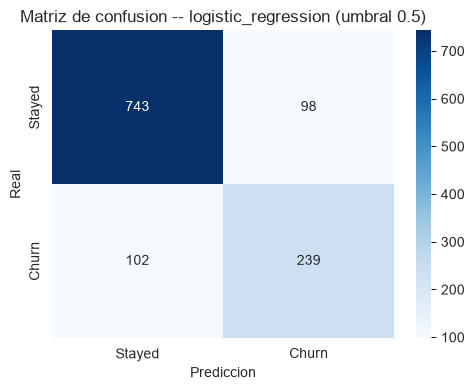

In [5]:
y_pred_best = models[BEST_MODEL_NAME].predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Stayed", "Churn"], yticklabels=["Stayed", "Churn"])
plt.title(f"Matriz de confusion -- {BEST_MODEL_NAME} (umbral 0.5)")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

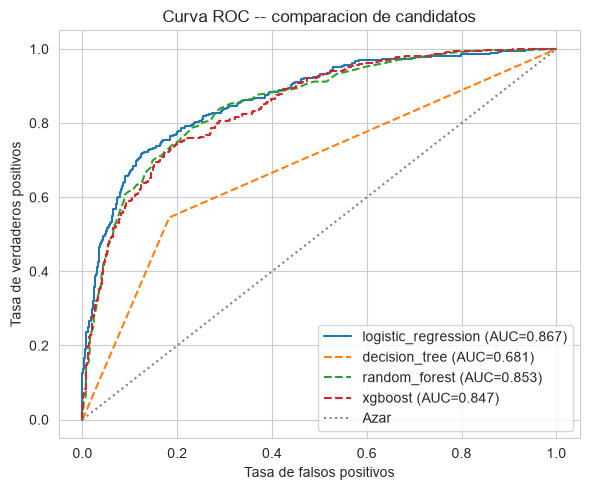

In [6]:
plt.figure(figsize=(6, 5))
for name, y_proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    style = "-" if name == BEST_MODEL_NAME else "--"
    plt.plot(fpr, tpr, style, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle=":", color="gray", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC -- comparacion de candidatos")
plt.legend()
plt.tight_layout()
plt.show()

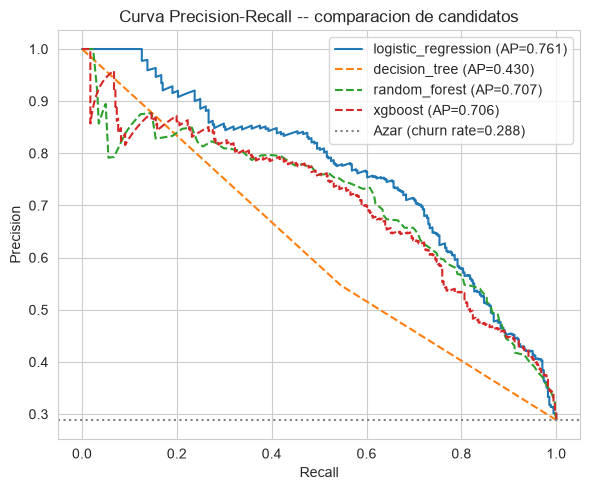

In [7]:
baseline = y_test.mean()

plt.figure(figsize=(6, 5))
for name, y_proba in probas.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    style = "-" if name == BEST_MODEL_NAME else "--"
    plt.plot(recall, precision, style, label=f"{name} (AP={ap:.3f})")

plt.axhline(baseline, linestyle=":", color="gray", label=f"Azar (churn rate={baseline:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall -- comparacion de candidatos")
plt.legend()
plt.tight_layout()
plt.show()

## Guardar el nombre del ganador para `08_final_model.ipynb`

In [8]:
with open(f"{MODELS_DIR}/best_model_name.txt", "w") as f:
    f.write(BEST_MODEL_NAME)

print(f"Guardado: best_model_name.txt -> {BEST_MODEL_NAME}")

Guardado: best_model_name.txt -> logistic_regression
